In [1]:
from rdkit import Chem
from rdkit.Chem.rdmolfiles import MolFromSmiles

ethanol=Chem.MolFromSmiles("CCO")
print(ethanol)

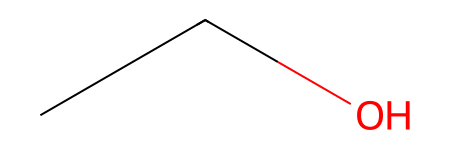

In [2]:
ethanol

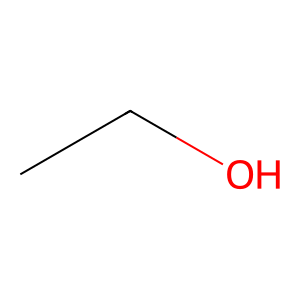

In [4]:
from rdkit.Chem import Draw
img=Draw.MolToImage(ethanol)
img

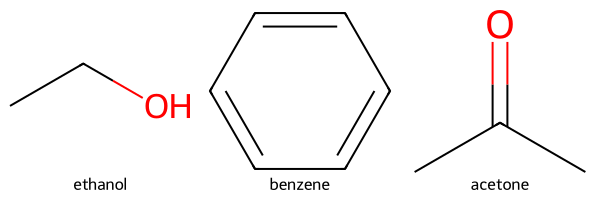

In [5]:
benzene=Chem.MolFromSmiles("c1ccccc1")
acetone=Chem.MolFromSmiles("CC(=O)C")
mols=[ethanol,benzene,acetone]
img2=Draw.MolsToImage(mols,legends=['ethanol','benzene','acetone'])
img2

In [17]:
from rdkit.Chem import Descriptors

logp = Descriptors.MolLogP(ethanol)
mw = Descriptors.MolWt(ethanol)
logp,mw

(-0.0014000000000000123, 46.069)

In [10]:
print(f"Benzene molecular weight: {Descriptors.MolWt(benzene):.2f}")
print(f"Benzene LogP: {Descriptors.MolLogP(benzene):.2f}")

Benzene molecular weight: 78.11
Benzene LogP: 1.69


In [18]:
heavey_count=ethanol.GetNumAtoms()
all_atom_count=ethanol.GetNumAtoms(onlyExplicit=False)
heavey_count,all_atom_count

(3, 9)

In [30]:
from rdkit import DataStructs
mol1=ethanol
mol2=Chem.MolFromSmiles("CCCO")

fp1=Chem.RDKFingerprint(mol1)
fp2=Chem.RDKFingerprint(mol2)
DataStructs.FingerprintSimilarity(fp1,fp2)

0.6

In [31]:
fp_benzene=Chem.RDKFingerprint(benzene)
DataStructs.FingerprintSimilarity(fp_benzene,fp2)

0.0

In [32]:
phenol=Chem.MolFromSmiles("c1ccccc1O")
match=phenol.HasSubstructMatch(benzene)
match

True

In [37]:
smiles_list = [
    "CC(=O)OC1=CC=CC=C1C(=O)O",  # Aspirin
    "c1ccccc1",                  # Benzene
    "CC(=O)O",                   # Acetic acid
    "CCO"                        # Ethanol
]
molecule_list = []
for smile in smiles_list:
    mol = Chem.MolFromSmiles(smile)
    if mol is not None:  # 确保分子转换成功
        molecule_list.append(mol)
    else:
        print(f"SMILES '{smile}' 转换失败")


filtered_mols = [mol for mol in molecule_list if Descriptors.MolWt(mol) < 200]
print("\n分子量>200的分子列表：", filtered_mols)


分子量>200的分子列表： [<rdkit.Chem.rdchem.Mol object at 0x000001AF6784C740>, <rdkit.Chem.rdchem.Mol object at 0x000001AF6784C820>, <rdkit.Chem.rdchem.Mol object at 0x000001AF6784C5F0>, <rdkit.Chem.rdchem.Mol object at 0x000001AF6784C9E0>]
